# Captain Cook Journal — Segmentation Pipeline

Pipeline: 
- Analysis 
- Deskew 
- YOLO Layout Detection 
- Kraken Line Segmentation 
- Line Crops 
- JSON Manifest

**Input:**  `data/Captain_Cook/Images_Bd4/*.jpg`

**Output:** `data/Captain_Cook/line_crops/<page_id>/`, `data/Captain_Cook/manifests/`

### Workflow
1. Analyse sample page — check image properties
2. Skew estimation and deskew
3. YOLO layout detection — find text blocks
4. Kraken line segmentation — within detected blocks
5. Extract and save line crops
6. Build JSON manifest per page and global manifest
7. Run full pipeline on all pages

In [1]:
import warnings
import os

# Suppress CoreML compatibility warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', message='.*NumPy.*')
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # suppress TensorFlow logs

import json
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw
from tqdm import tqdm

from skimage.filters import threshold_sauvola
from skimage.color import rgb2gray
from scipy.ndimage import rotate as nd_rotate

warnings.filterwarnings('ignore')

## Cell 1 - Data paths

In [2]:
# ── Project root ─────────────────────────────────────────────────────
REPO_ROOT = Path.cwd()

# ── Captain Cook data paths ──────────────────────────────────────────
DATA_DIR     = REPO_ROOT / 'data' / 'Captain_Cook' / 'Images_Bd3'
CROPS_DIR    = REPO_ROOT / 'data' / 'Captain_Cook' / 'line_crops_Bd3'
MANIFEST_DIR = REPO_ROOT / 'data' / 'Captain_Cook' / 'manifests_Bd3'

CROPS_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

# ── Segmentation parameters ───────────────────────────────────────────
SKEW_THRESHOLD_DEG = 0.5    # deskew only if |angle| > threshold
PAD_TOP_PX         = 18     # padding above baseline for ascenders
PAD_BOTTOM_PX      = 12     # padding below baseline for descenders
SAUVOLA_WIN_SIZE   = 51     # window size for adaptive thresholding
SAUVOLA_K          = 0.15

# ── YOLO classes treated as text regions ────────────────────────────
# DocLayout-YOLO classes: title, plain text, abandon, figure,
# figure_caption, table, table_caption, table_footnote,
# isolate_formula, formula_caption
# For handwritten manuscripts YOLO often returns 'figure' — we accept all
YOLO_TEXT_CLASSES = {'plain text', 'title', 'figure'}
YOLO_CONF         = 0.15    # low threshold — manuscript pages are unusual for YOLO

# ── Find all page images ─────────────────────────────────────────────
JPEG_FILES = sorted(DATA_DIR.glob('*.jpg'))
print(f'Pages found: {len(JPEG_FILES)}')
for f in JPEG_FILES:
    print(f'  {f.name}')

Pages found: 151
  B3_P_012.jpg
  B3_P_014.jpg
  B3_P_015.jpg
  B3_P_016.jpg
  B3_P_017.jpg
  B3_P_020.jpg
  B3_P_021.jpg
  B3_P_024.jpg
  B3_P_025.jpg
  B3_P_028.jpg
  B3_P_029.jpg
  B3_P_032.jpg
  B3_P_033.jpg
  B3_P_036.jpg
  B3_P_037.jpg
  B3_P_040.jpg
  B3_P_041.jpg
  B3_P_044.jpg
  B3_P_045.jpg
  B3_P_048.jpg
  B3_P_049.jpg
  B3_P_052.jpg
  B3_P_053.jpg
  B3_P_056.jpg
  B3_P_057.jpg
  B3_P_060.jpg
  B3_P_061.jpg
  B3_P_064.jpg
  B3_P_065.jpg
  B3_P_068.jpg
  B3_P_069.jpg
  B3_P_072.jpg
  B3_P_073.jpg
  B3_P_074.jpg
  B3_P_075.jpg
  B3_P_078.jpg
  B3_P_079.jpg
  B3_P_082.jpg
  B3_P_083.jpg
  B3_P_086.jpg
  B3_P_087.jpg
  B3_P_088.jpg
  B3_P_089.jpg
  B3_P_090.jpg
  B3_P_091.jpg
  B3_P_092.jpg
  B3_P_093.jpg
  B3_P_096.jpg
  B3_P_097.jpg
  B3_P_100.jpg
  B3_P_101.jpg
  B3_P_104.jpg
  B3_P_105.jpg
  B3_P_108.jpg
  B3_P_109.jpg
  B3_P_112.jpg
  B3_P_113.jpg
  B3_P_116.jpg
  B3_P_117.jpg
  B3_P_120.jpg
  B3_P_121.jpg
  B3_P_124.jpg
  B3_P_125.jpg
  B3_P_128.jpg
  B3_P_129.jpg
  B3_P_1

## Cell 2 — Analyse sample page

File       : B3_P_012.jpg
Resolution : 1781 x 2618 px
Mode       : RGB
File size  : 624 KB

Brightness (Mean/Std): 177.1 / 51.4
Dark (<100): 12.7%  (~ink coverage)
Light (>200): 42.0%  (~background)


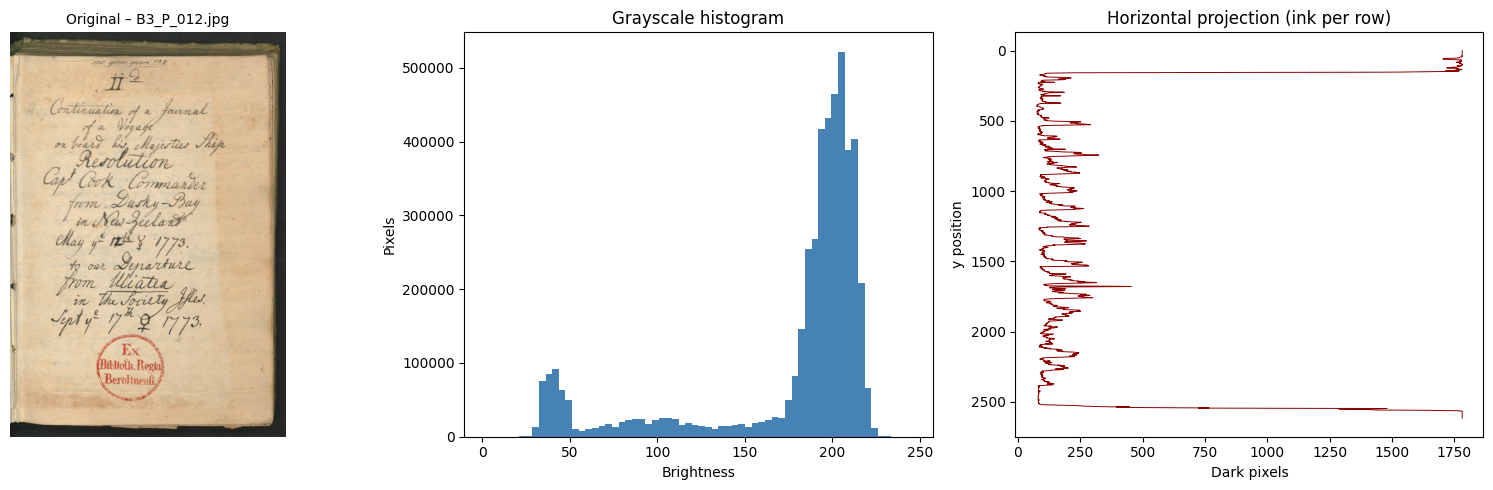

Quadrant brightness:
  top-left      : 183.7
  top-right     : 167.5
  bottom-left   : 187.2
  bottom-right  : 170.1
  Range: 19.7 (>15 → Sauvola recommended)


In [3]:
SAMPLE     = JPEG_FILES[0]
sample_pil = Image.open(SAMPLE)
sample_np  = np.array(sample_pil)
sample_gray = np.array(sample_pil.convert('L'))

print(f'File       : {SAMPLE.name}')
print(f'Resolution : {sample_pil.size[0]} x {sample_pil.size[1]} px')
print(f'Mode       : {sample_pil.mode}')
print(f'File size  : {SAMPLE.stat().st_size // 1024} KB')
print()
print(f'Brightness (Mean/Std): {sample_gray.mean():.1f} / {sample_gray.std():.1f}')
print(f'Dark (<100): {100*(sample_gray<100).mean():.1f}%  (~ink coverage)')
print(f'Light (>200): {100*(sample_gray>200).mean():.1f}%  (~background)')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(sample_pil)
axes[0].set_title(f'Original – {SAMPLE.name}', fontsize=10)
axes[0].axis('off')

axes[1].hist(sample_gray.ravel(), bins=64, color='steelblue', edgecolor='none')
axes[1].set_title('Grayscale histogram')
axes[1].set_xlabel('Brightness')
axes[1].set_ylabel('Pixels')

# Horizontal projection profile — dark pixels per row → text line pattern
proj = (sample_gray < 128).sum(axis=1)
axes[2].plot(proj, np.arange(len(proj)), color='darkred', lw=0.7)
axes[2].invert_yaxis()
axes[2].set_title('Horizontal projection (ink per row)')
axes[2].set_xlabel('Dark pixels')
axes[2].set_ylabel('y position')

plt.tight_layout()
plt.show()

# Brightness uniformity across 4 quadrants
h, w = sample_gray.shape
quads = {
    'top-left'    : sample_gray[:h//2, :w//2],
    'top-right'   : sample_gray[:h//2, w//2:],
    'bottom-left' : sample_gray[h//2:, :w//2],
    'bottom-right': sample_gray[h//2:, w//2:],
}
means = {k: v.mean() for k, v in quads.items()}
print('Quadrant brightness:')
for k, m in means.items():
    print(f'  {k:<14}: {m:.1f}')
print(f'  Range: {max(means.values())-min(means.values()):.1f} (>15 → Sauvola recommended)')

## Cell 3 — Skew estimation and deskew

Cook journal pages show slight tilts between 0° and ~2°.
Even small angles degrade Kraken's baseline detection.
Deskew is applied when |angle| > 0.5°.

File                    Angle  Deskew?
------------------------------------------
B3_P_012.jpg           +0.00°  no
B3_P_014.jpg           +0.00°  no
B3_P_015.jpg           +0.00°  no
B3_P_016.jpg           +0.00°  no
B3_P_017.jpg           +1.13°  yes
B3_P_020.jpg           +1.56°  yes
B3_P_021.jpg           +0.00°  no
B3_P_024.jpg           +0.97°  yes
B3_P_025.jpg           +0.00°  no
B3_P_028.jpg           +0.00°  no
B3_P_029.jpg           +0.00°  no
B3_P_032.jpg           +0.00°  no
B3_P_033.jpg           +0.88°  yes
B3_P_036.jpg           +0.00°  no
B3_P_037.jpg           +0.00°  no
B3_P_040.jpg           +1.11°  yes
B3_P_041.jpg           +1.67°  yes
B3_P_044.jpg           +1.00°  yes
B3_P_045.jpg           +0.00°  no
B3_P_048.jpg           +0.00°  no
B3_P_049.jpg           +0.74°  yes
B3_P_052.jpg           +0.00°  no
B3_P_053.jpg           +0.00°  no
B3_P_056.jpg           +0.00°  no
B3_P_057.jpg           +0.56°  yes
B3_P_060.jpg           +0.00°  no
B3_P_061.jpg           +0

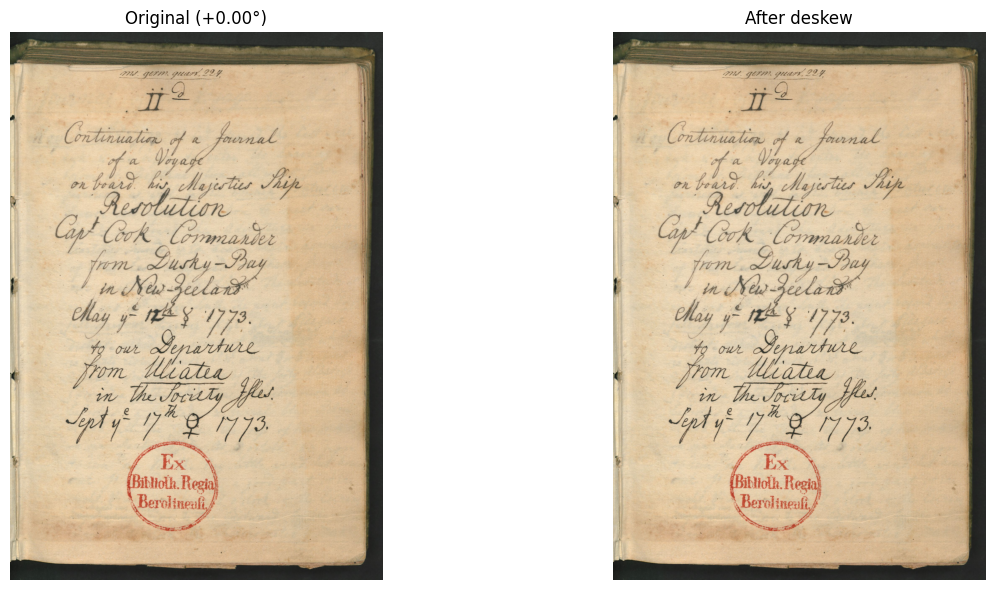

In [4]:
def estimate_skew(gray: np.ndarray) -> float:
    """Estimate skew angle using HoughLinesP on near-horizontal lines."""
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(
        edges, 1, np.pi / 180,
        threshold=100, minLineLength=100, maxLineGap=10
    )
    if lines is None:
        return 0.0
    angles = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        if x2 != x1:
            angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
            if abs(angle) < 10:   # only near-horizontal lines
                angles.append(angle)
    return float(np.median(angles)) if angles else 0.0


def deskew_image(pil_img: Image.Image, angle: float) -> Image.Image:
    """Rotate PIL image by angle degrees; fill corners with white."""
    if abs(angle) <= SKEW_THRESHOLD_DEG:
        return pil_img
    arr     = np.array(pil_img)
    rotated = nd_rotate(arr, angle, reshape=False, cval=255, mode='constant')
    return Image.fromarray(rotated.astype(np.uint8))


# Analyse skew for all pages
skew_results = {}
print(f'{"File":<20} {"Angle":>8}  {"Deskew?"}')
print('-' * 42)
for jpg in JPEG_FILES:
    gray  = np.array(Image.open(jpg).convert('L'))
    angle = estimate_skew(gray)
    needs = abs(angle) > SKEW_THRESHOLD_DEG
    skew_results[jpg.stem] = angle
    print(f'{jpg.name:<20} {angle:>+7.2f}°  {"yes" if needs else "no"}')

# Visualise deskew on sample page
angle_sample    = skew_results[SAMPLE.stem]
deskewed_sample = deskew_image(sample_pil, angle_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(sample_pil);     axes[0].set_title(f'Original ({angle_sample:+.2f}°)'); axes[0].axis('off')
axes[1].imshow(deskewed_sample); axes[1].set_title('After deskew'); axes[1].axis('off')
plt.tight_layout()
plt.show()

## Cell 4 — YOLO layout detection

DocLayout-YOLO detects text block regions on the page.
Kraken then segments lines only within those regions —
preventing margin marks and page numbers being treated as text lines.

Note: This model was trained on printed documents.
For handwritten manuscripts it often returns 'figure' for the main text block —
we accept this and use the bounding box regardless of label.

In [5]:
from huggingface_hub import hf_hub_download
from doclayout_yolo import YOLOv10

YOLO_MODEL_REPO = 'juliozhao/DocLayout-YOLO-DocStructBench'
YOLO_MODEL_FILE = 'doclayout_yolo_docstructbench_imgsz1024.pt'

try:
    model_path = hf_hub_download(
        repo_id  = YOLO_MODEL_REPO,
        filename = YOLO_MODEL_FILE
    )
    yolo_model     = YOLOv10(model_path)
    YOLO_AVAILABLE = True
    print(f'DocLayout-YOLO loaded: {YOLO_MODEL_FILE}')
    print(f'Classes: {list(yolo_model.names.values())}')
except Exception as e:
    YOLO_AVAILABLE = False
    print(f'YOLO not available: {e}')
    print('Fallback: using full page as text region.')

DocLayout-YOLO loaded: doclayout_yolo_docstructbench_imgsz1024.pt
Classes: ['title', 'plain text', 'abandon', 'figure', 'figure_caption', 'table', 'table_caption', 'table_footnote', 'isolate_formula', 'formula_caption']


2 text region(s) detected:
  figure       conf=0.69  bbox=[0, 10, 1495, 2618]
  figure       conf=0.19  bbox=[0, 12, 1781, 2615]


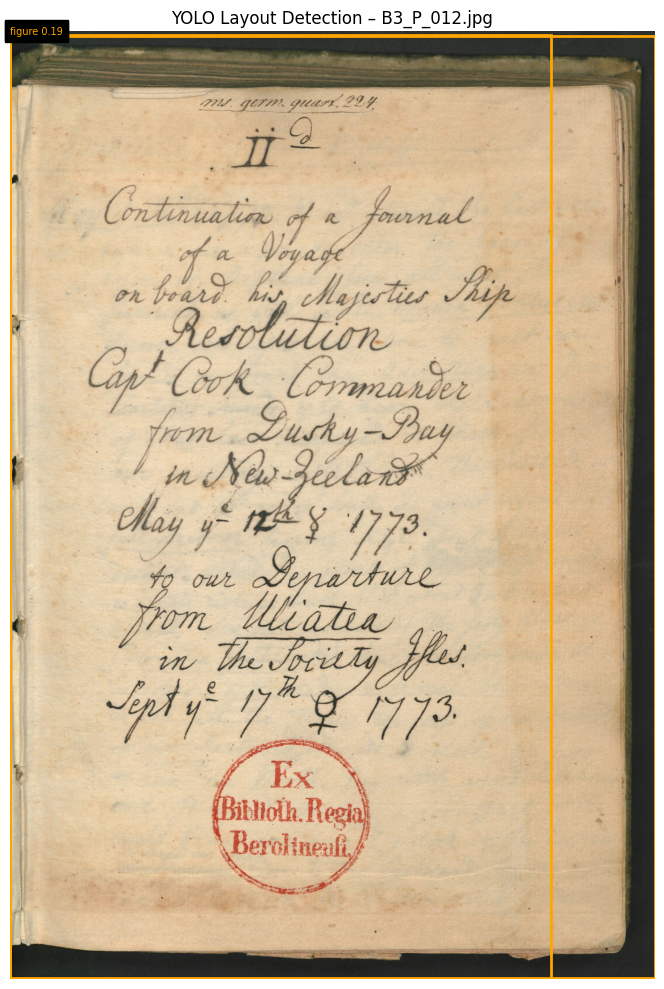

In [6]:
def detect_text_regions(pil_img: Image.Image) -> list[dict]:
    W, H = pil_img.size

    if not YOLO_AVAILABLE:
        return [{'bbox': [0, 0, W, H], 'label': 'text', 'conf': 1.0}]

    results = yolo_model.predict(
        pil_img,
        imgsz=1024,
        conf=YOLO_CONF,
        verbose=False,
        device='mps'
    )

    regions = []
    for box in results[0].boxes:
        cls_name = yolo_model.names[int(box.cls)]
        conf     = float(box.conf)
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0]]

        box_w = x2 - x1
        box_h = y2 - y1

        # Extend top to catch missed first lines (12% of box height)
        extend_top = int(box_h * 0.12)

        # Extend left/right by 8% of box width — catches clipped
        # first/last words on each line, which YOLO often misses
        extend_x = int(box_w * 0.08)

        x1 = max(0, x1 - extend_x)
        x2 = min(W, x2 + extend_x)
        y1 = max(0, y1 - extend_top)
        y2 = min(H, y2 + 10)

        regions.append({
            'bbox' : [x1, y1, x2, y2],
            'label': cls_name,
            'conf' : conf
        })

    text_regions = [r for r in regions if r['label'] in YOLO_TEXT_CLASSES]

    if not text_regions and regions:
        largest = max(
            regions,
            key=lambda r: (r['bbox'][2]-r['bbox'][0]) * (r['bbox'][3]-r['bbox'][1])
        )
        text_regions = [largest]

    if not text_regions:
        return [{'bbox': [0, 0, W, H], 'label': 'text', 'conf': 1.0}]

    return text_regions

def visualize_regions(pil_img: Image.Image, regions: list[dict], title: str = ''):
    fig, ax = plt.subplots(figsize=(7, 10))
    ax.imshow(pil_img)
    colors = {
        'plain text': 'lime', 'title': 'cyan',
        'figure': 'orange',   'text': 'lime'
    }
    for r in regions:
        x1, y1, x2, y2 = r['bbox']
        c    = colors.get(r['label'], 'red')
        rect = mpatches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=c, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1-4, f"{r['label']} {r['conf']:.2f}",
                color=c, fontsize=7, backgroundcolor='black')
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# Test on sample page
sample_regions = detect_text_regions(deskewed_sample)
print(f'{len(sample_regions)} text region(s) detected:')
for r in sample_regions:
    print(f"  {r['label']:<12} conf={r['conf']:.2f}  bbox={r['bbox']}")
visualize_regions(deskewed_sample, sample_regions,
                  title=f'YOLO Layout Detection – {SAMPLE.name}')

## Cell 5 — Kraken line segmentation

Kraken's `blla.segment()` detects baselines and boundary polygons.
Segmentation runs per detected text region — coordinates are
shifted back to full-page coordinates after cropping.

In [7]:
from kraken import blla

KRAKEN_MODEL = None   # None = blla default model

print('Kraken ready. Model: default (blla)')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/hedyeh/Ginger_Gradient/Capstone-Project/.venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/hedyeh/Ginger_Gradient/Capstone-Project/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/Users/hedyeh/Ginger_Gradient/Capstone-Project/.venv/lib/python3.11/site-package

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/hedyeh/Ginger_Gradient/Capstone-Project/.venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/hedyeh/Ginger_Gradient/Capstone-Project/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/Users/hedyeh/Ginger_Gradient/Capstone-Project/.venv/lib/python3.11/site-package

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/hedyeh/Ginger_Gradient/Capstone-Project/.venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/hedyeh/Ginger_Gradient/Capstone-Project/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/Users/hedyeh/Ginger_Gradient/Capstone-Project/.venv/lib/python3.11/site-package

AttributeError: _ARRAY_API not found

ImportError: numpy.core._multiarray_umath failed to import

Kraken ready. Model: default (blla)


Segmenting sample page...
Lines detected: 36
Baseline points line 1: [(516, 205), (1012, 205)] ...
Boundary points line 1: 34


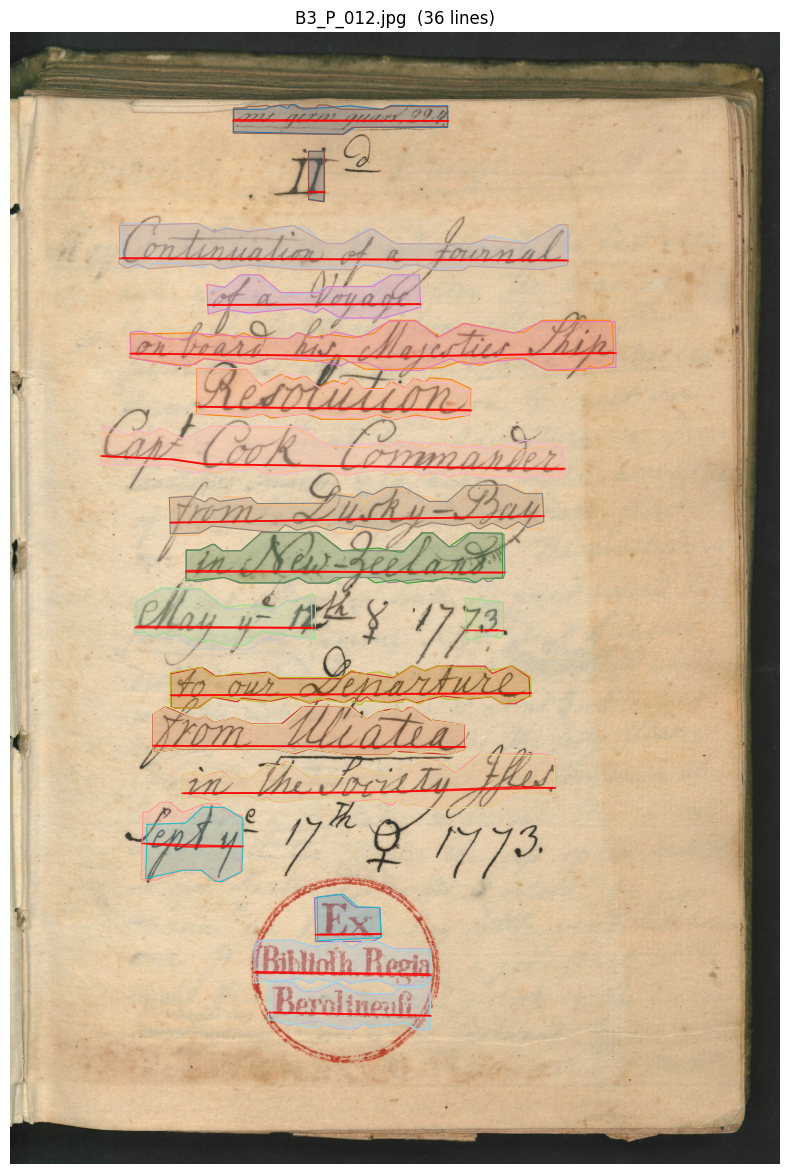

In [8]:
def segment_page_kraken(pil_img: Image.Image, regions: list[dict]) -> list:
    """
    Run Kraken blla segmentation within each detected text region.
    Shifts baseline and boundary coordinates back to full-page space.
    Returns list of line objects.
    """
    all_lines = []
    W, H      = pil_img.size

    for region in regions:
        x1, y1, x2, y2 = region['bbox']
        crop            = pil_img.crop((x1, y1, x2, y2))
        seg             = blla.segment(crop, model=KRAKEN_MODEL)

        for line in seg.lines:
            # Shift coordinates back to full-page space
            line.baseline = [(px + x1, py + y1) for px, py in line.baseline]
            line.boundary = [(px + x1, py + y1) for px, py in line.boundary]
            line._region_label = region['label']
            all_lines.append(line)

    return all_lines


def visualize_segmentation(pil_img, lines, title='', max_lines=60):
    fig, ax = plt.subplots(figsize=(8, 12))
    ax.imshow(pil_img)
    cmap = plt.colormaps['tab20'].resampled(min(len(lines), max_lines))
    for i, line in enumerate(lines[:max_lines]):
        color = cmap(i % max_lines)
        if line.boundary:
            bnd = np.array(line.boundary)
            ax.fill(bnd[:,0], bnd[:,1], alpha=0.18, color=color)
            ax.plot(
                np.append(bnd[:,0], bnd[0,0]),
                np.append(bnd[:,1], bnd[0,1]),
                '-', lw=0.7, color=color
            )
        if line.baseline:
            bl = np.array(line.baseline)
            ax.plot(bl[:,0], bl[:,1], 'r-', lw=1.2, alpha=0.8)
    ax.set_title(f'{title}  ({len(lines)} lines)')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# Test segmentation on sample page
print('Segmenting sample page...')
sample_lines = segment_page_kraken(deskewed_sample, sample_regions)
print(f'Lines detected: {len(sample_lines)}')
if sample_lines:
    print(f'Baseline points line 1: {sample_lines[0].baseline[:3]} ...')
    print(f'Boundary points line 1: {len(sample_lines[0].boundary)}')

visualize_segmentation(deskewed_sample, sample_lines, title=SAMPLE.name)

## Cell 6 — Extract and save line crops

Uses the boundary polygon bounding box with padding for ascenders and descenders.
Saves each line as a JPG image.

  [WARN] B3_P_012_L01 height=99px — check manually
  [WARN] B3_P_012_L03 height=135px — check manually
  [WARN] B3_P_012_L04 height=130px — check manually
  [WARN] B3_P_012_L05 height=146px — check manually
  [WARN] B3_P_012_L06 height=149px — check manually
  [WARN] B3_P_012_L07 height=150px — check manually
  [WARN] B3_P_012_L08 height=145px — check manually
  [WARN] B3_P_012_L09 height=148px — check manually
  [WARN] B3_P_012_L10 height=163px — check manually
  [WARN] B3_P_012_L12 height=127px — check manually
  [WARN] B3_P_012_L13 height=143px — check manually
  [WARN] B3_P_012_L14 height=157px — check manually
  [WARN] B3_P_012_L17 height=133px — check manually
  [WARN] B3_P_012_L18 height=141px — check manually
  [WARN] B3_P_012_L19 height=98px — check manually
  [WARN] B3_P_012_L21 height=139px — check manually
  [WARN] B3_P_012_L22 height=130px — check manually
  [WARN] B3_P_012_L23 height=144px — check manually
  [WARN] B3_P_012_L24 height=148px — check manually
  [WARN] B3_P_

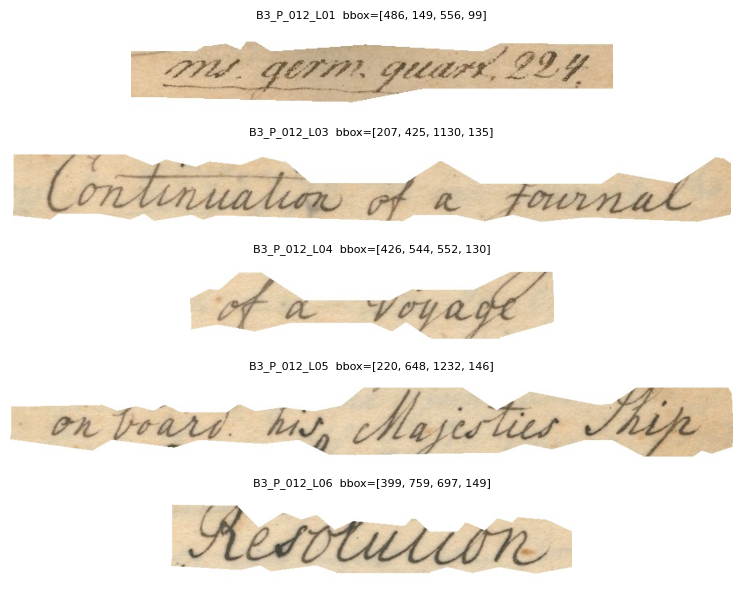

In [9]:
def extract_line_crops(
    pil_img   : Image.Image,
    lines     : list,
    page_id   : str,
    out_dir   : Path,
    pad_top   : int = PAD_TOP_PX,
    pad_bottom: int = PAD_BOTTOM_PX,
) -> list[dict]:
    W, H = pil_img.size
    out_dir.mkdir(parents=True, exist_ok=True)
    records = []

    for idx, line in enumerate(lines):
        if not line.boundary:
            continue

        pts = np.array(line.boundary, dtype=int)

        x1_raw = int(pts[:, 0].min())
        x2_raw = int(pts[:, 0].max())
        y1_raw = int(pts[:, 1].min())
        y2_raw = int(pts[:, 1].max())

        line_w = x2_raw - x1_raw

        # ── KEY FIX: generous horizontal padding ────────────────────
        # 30px fixed + 5% of line width — covers both short and long
        # lines, preventing first/last word clipping seen previously
        pad_x = max(30, int(line_w * 0.05))

        x1 = max(0, x1_raw - pad_x)
        x2 = min(W, x2_raw + pad_x)
        y1 = max(0, y1_raw - pad_top)
        y2 = min(H, y2_raw + pad_bottom)

        # Skip degenerate boxes
        if x2 - x1 < 10 or y2 - y1 < 5:
            continue

        # Skip vertical margin lines
        if (x2 - x1) < (y2 - y1) * 2:
            continue

        # ── Polygon mask, extended outward to match the padded crop ──
        # Without this extension, the mask would blank out the extra
        # padding we just added, reintroducing the clipping problem.
        crop_region = pil_img.crop((x1, y1, x2, y2))
        mask        = Image.new('L', crop_region.size, 0)
        draw        = ImageDraw.Draw(mask)

        cx = sum(p[0] for p in line.boundary) / len(line.boundary)
        extended_boundary = [
            (px + (pad_x if px >= cx else -pad_x), py)
            for px, py in line.boundary
        ]

        shifted_pts = [
            (px - x1, py - y1)
            for px, py in extended_boundary
        ]
        draw.polygon(shifted_pts, fill=255)

        white  = Image.new('RGB', crop_region.size, (255, 255, 255))
        masked = Image.composite(crop_region, white, mask)

        crop_h = y2 - y1
        if crop_h > 80:
            print(f"  [WARN] {page_id}_L{idx+1:02d} height={crop_h}px "
                  f"— check manually")

        line_id  = f'{page_id}_L{idx+1:02d}'
        filename = f'{line_id}.jpg'
        masked.save(out_dir / filename, quality=95)

        records.append({
            'line_id'     : line_id,
            'line_image'  : str((out_dir / filename).relative_to(REPO_ROOT)),
            'bbox'        : [x1, y1, x2 - x1, y2 - y1],
            'baseline'    : [list(p) for p in line.baseline],
            'boundary'    : [list(p) for p in line.boundary],
            'region_label': getattr(line, '_region_label', 'text'),
        })

    return records

# Test on sample page
sample_out_dir  = CROPS_DIR / SAMPLE.stem
sample_records  = extract_line_crops(
    deskewed_sample, sample_lines, SAMPLE.stem, sample_out_dir
)
print(f'Line images saved: {len(sample_records)}')
print(f'Output directory : {sample_out_dir}')

# Preview first 5 lines
if sample_records:
    fig, axes = plt.subplots(min(5, len(sample_records)), 1, figsize=(14, 6))
    if len(sample_records) == 1:
        axes = [axes]
    for ax, rec in zip(axes, sample_records[:5]):
        img = Image.open(REPO_ROOT / rec['line_image'])
        ax.imshow(img)
        ax.set_title(f"{rec['line_id']}  bbox={rec['bbox']}", fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Cell 7 — JSON manifest

Two levels:
- **Page manifest** `data/Captain_Cook/manifests/<page_id>.json` — full metadata for one page
- **Global manifest** `data/Captain_Cook/manifests/manifest.json` — all pages as a list

In [10]:
def build_page_manifest(
    page_id     : str,
    source_image: Path,
    skew_angle  : float,
    regions     : list[dict],
    line_records: list[dict],
) -> dict:
    return {
        'page_id'        : page_id,
        'source_image'   : str(source_image.relative_to(REPO_ROOT)),
        'image_size'     : list(Image.open(source_image).size),
        'skew_angle_deg' : round(skew_angle, 3),
        'deskewed'       : abs(skew_angle) > SKEW_THRESHOLD_DEG,
        'n_regions'      : len(regions),
        'n_lines'        : len(line_records),
        'regions'        : [
            {'label': r['label'], 'bbox': r['bbox'], 'conf': round(r['conf'], 3)}
            for r in regions
        ],
        'lines'          : line_records,
    }


def save_page_manifest(manifest: dict, out_dir: Path) -> Path:
    path = out_dir / f"{manifest['page_id']}.json"
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(manifest, f, ensure_ascii=False, indent=2)
    return path


def save_global_manifest(page_manifests: list[dict], out_dir: Path) -> Path:
    summary = []
    for m in page_manifests:
        summary.append({
            'page_id'       : m['page_id'],
            'source_image'  : m['source_image'],
            'n_lines'       : m['n_lines'],
            'skew_angle_deg': m['skew_angle_deg'],
            'manifest_path' : str(out_dir / f"{m['page_id']}.json"),
        })
    global_path = out_dir / 'manifest.json'
    with open(global_path, 'w', encoding='utf-8') as f:
        json.dump(
            {'pages': summary, 'total_lines': sum(s['n_lines'] for s in summary)},
            f, ensure_ascii=False, indent=2
        )
    return global_path


# Save sample page manifest
sample_manifest = build_page_manifest(
    SAMPLE.stem, SAMPLE,
    skew_results[SAMPLE.stem],
    sample_regions, sample_records
)
path = save_page_manifest(sample_manifest, MANIFEST_DIR)
print(f'Page manifest saved: {path}')
print(json.dumps({
    'page_id'       : sample_manifest['page_id'],
    'n_lines'       : sample_manifest['n_lines'],
    'skew_angle_deg': sample_manifest['skew_angle_deg'],
    'deskewed'      : sample_manifest['deskewed'],
    'first_line'    : sample_manifest['lines'][0] if sample_manifest['lines'] else None,
}, indent=2))

Page manifest saved: /Users/hedyeh/Ginger_Gradient/Capstone-Project/data/Captain_Cook/manifests_Bd3/B3_P_012.json
{
  "page_id": "B3_P_012",
  "n_lines": 28,
  "skew_angle_deg": 0.0,
  "deskewed": false,
  "first_line": {
    "line_id": "B3_P_012_L01",
    "line_image": "data/Captain_Cook/line_crops_Bd3/B3_P_012/B3_P_012_L01.jpg",
    "bbox": [
      486,
      149,
      556,
      99
    ],
    "baseline": [
      [
        516,
        205
      ],
      [
        1012,
        205
      ]
    ],
    "boundary": [
      [
        1009,
        170
      ],
      [
        994,
        170
      ],
      [
        980,
        170
      ],
      [
        965,
        170
      ],
      [
        951,
        170
      ],
      [
        936,
        169
      ],
      [
        922,
        169
      ],
      [
        907,
        169
      ],
      [
        893,
        169
      ],
      [
        881,
        169
      ],
      [
        861,
        178
      ],
      [
      

## Cell 8 — Full pipeline: all pages

In [11]:
all_manifests = []

for jpg in tqdm(JPEG_FILES, desc='Processing pages'):
    page_id = jpg.stem

    # 1. Load
    pil_img = Image.open(jpg).convert('RGB')

    # 2. Deskew
    angle   = skew_results.get(page_id, 0.0)
    pil_img = deskew_image(pil_img, angle)

    # 3. YOLO layout detection
    regions = detect_text_regions(pil_img)

    # 4. Kraken line segmentation
    lines = segment_page_kraken(pil_img, regions)

    # 5. Save line crops
    out_dir      = CROPS_DIR / page_id
    line_records = extract_line_crops(pil_img, lines, page_id, out_dir)

    # 6. Page manifest
    manifest = build_page_manifest(page_id, jpg, angle, regions, line_records)
    save_page_manifest(manifest, MANIFEST_DIR)
    all_manifests.append(manifest)

    tqdm.write(f'{page_id}: {len(line_records)} lines saved, skew {angle:+.2f}°')

# 7. Global manifest
global_path = save_global_manifest(all_manifests, MANIFEST_DIR)
print(f'\nGlobal manifest saved: {global_path}')

Processing pages:   1%|          | 1/151 [00:06<15:17,  6.11s/it]

  [WARN] B3_P_012_L01 height=99px — check manually
  [WARN] B3_P_012_L03 height=135px — check manually
  [WARN] B3_P_012_L04 height=130px — check manually
  [WARN] B3_P_012_L05 height=146px — check manually
  [WARN] B3_P_012_L06 height=149px — check manually
  [WARN] B3_P_012_L07 height=150px — check manually
  [WARN] B3_P_012_L08 height=145px — check manually
  [WARN] B3_P_012_L09 height=148px — check manually
  [WARN] B3_P_012_L10 height=163px — check manually
  [WARN] B3_P_012_L12 height=127px — check manually
  [WARN] B3_P_012_L13 height=143px — check manually
  [WARN] B3_P_012_L14 height=157px — check manually
  [WARN] B3_P_012_L17 height=133px — check manually
  [WARN] B3_P_012_L18 height=141px — check manually
  [WARN] B3_P_012_L19 height=98px — check manually
  [WARN] B3_P_012_L21 height=139px — check manually
  [WARN] B3_P_012_L22 height=130px — check manually
  [WARN] B3_P_012_L23 height=144px — check manually
  [WARN] B3_P_012_L24 height=148px — check manually
  [WARN] B3_P_

Processing pages:   1%|▏         | 2/151 [00:10<12:56,  5.21s/it]

  [WARN] B3_P_014_L01 height=130px — check manually
  [WARN] B3_P_014_L02 height=171px — check manually
  [WARN] B3_P_014_L03 height=116px — check manually
  [WARN] B3_P_014_L04 height=133px — check manually
  [WARN] B3_P_014_L05 height=125px — check manually
  [WARN] B3_P_014_L06 height=115px — check manually
  [WARN] B3_P_014_L07 height=136px — check manually
  [WARN] B3_P_014_L08 height=123px — check manually
  [WARN] B3_P_014_L09 height=131px — check manually
  [WARN] B3_P_014_L10 height=135px — check manually
  [WARN] B3_P_014_L11 height=135px — check manually
  [WARN] B3_P_014_L12 height=117px — check manually
  [WARN] B3_P_014_L14 height=106px — check manually
  [WARN] B3_P_014_L15 height=134px — check manually
  [WARN] B3_P_014_L16 height=129px — check manually
  [WARN] B3_P_014_L17 height=132px — check manually
  [WARN] B3_P_014_L18 height=113px — check manually
  [WARN] B3_P_014_L19 height=119px — check manually
  [WARN] B3_P_014_L20 height=124px — check manually
  [WARN] B3_

Processing pages:   2%|▏         | 3/151 [00:15<12:19,  5.00s/it]

...

  [WARN] B3_P_277_L01 height=120px — check manually
  [WARN] B3_P_277_L02 height=101px — check manually
  [WARN] B3_P_277_L03 height=102px — check manually
  [WARN] B3_P_277_L05 height=113px — check manually
  [WARN] B3_P_277_L06 height=126px — check manually
  [WARN] B3_P_277_L07 height=111px — check manually
  [WARN] B3_P_277_L08 height=108px — check manually
  [WARN] B3_P_277_L09 height=108px — check manually
  [WARN] B3_P_277_L11 height=114px — check manually
  [WARN] B3_P_277_L13 height=119px — check manually
  [WARN] B3_P_277_L14 height=126px — check manually
  [WARN] B3_P_277_L15 height=127px — check manually
  [WARN] B3_P_277_L16 height=137px — check manually
  [WARN] B3_P_277_L17 height=135px — check manually
  [WARN] B3_P_277_L18 height=135px — check manually
  [WARN] B3_P_277_L19 height=113px — check manually
  [WARN] B3_P_277_L20 height=128px — check manually
  [WARN] B3_P_277_L21 height=122px — check manually
  [WARN] B3_P_277_L22 height=124px — check manually
  [WARN] B3_

Processing pages:  99%|█████████▉| 150/151 [13:57<00:06,  6.24s/it]

  [WARN] B3_P_280_L01 height=93px — check manually
  [WARN] B3_P_280_L02 height=106px — check manually
  [WARN] B3_P_280_L04 height=120px — check manually
  [WARN] B3_P_280_L05 height=114px — check manually
  [WARN] B3_P_280_L06 height=134px — check manually
  [WARN] B3_P_280_L07 height=136px — check manually
  [WARN] B3_P_280_L08 height=122px — check manually
  [WARN] B3_P_280_L09 height=116px — check manually
  [WARN] B3_P_280_L10 height=135px — check manually
  [WARN] B3_P_280_L11 height=128px — check manually
  [WARN] B3_P_280_L12 height=111px — check manually
  [WARN] B3_P_280_L13 height=115px — check manually
  [WARN] B3_P_280_L14 height=129px — check manually
  [WARN] B3_P_280_L15 height=134px — check manually
  [WARN] B3_P_280_L16 height=127px — check manually
  [WARN] B3_P_280_L17 height=172px — check manually
  [WARN] B3_P_280_L18 height=153px — check manually
  [WARN] B3_P_280_L19 height=148px — check manually
  [WARN] B3_P_280_L20 height=144px — check manually
  [WARN] B3_P

Processing pages: 100%|██████████| 151/151 [14:10<00:00,  5.63s/it]

  [WARN] B3_P_281_L09 height=82px — check manually
  [WARN] B3_P_281_L12 height=84px — check manually
  [WARN] B3_P_281_L18 height=88px — check manually
  [WARN] B3_P_281_L19 height=81px — check manually
  [WARN] B3_P_281_L27 height=91px — check manually
  [WARN] B3_P_281_L34 height=87px — check manually
  [WARN] B3_P_281_L35 height=90px — check manually
  [WARN] B3_P_281_L36 height=86px — check manually
  [WARN] B3_P_281_L38 height=81px — check manually
  [WARN] B3_P_281_L48 height=105px — check manually
  [WARN] B3_P_281_L50 height=129px — check manually
  [WARN] B3_P_281_L52 height=119px — check manually
  [WARN] B3_P_281_L53 height=133px — check manually
  [WARN] B3_P_281_L54 height=121px — check manually
  [WARN] B3_P_281_L56 height=131px — check manually
  [WARN] B3_P_281_L57 height=116px — check manually
  [WARN] B3_P_281_L58 height=133px — check manually
  [WARN] B3_P_281_L59 height=141px — check manually
  [WARN] B3_P_281_L62 height=136px — check manually
  [WARN] B3_P_281_L63

## Cell 9 — Summary

In [12]:
with open(MANIFEST_DIR / 'manifest.json') as f:
    gm = json.load(f)

print(f"Pages processed  : {len(gm['pages'])}")
print(f"Total lines      : {gm['total_lines']}")
print(f"Average per page : {gm['total_lines']/len(gm['pages']):.1f}")
print()
print(f"{'Page':<20} {'Lines':>7}  {'Skew':>7}")
print('-' * 38)
for p in gm['pages']:
    print(f"{p['page_id']:<20} {p['n_lines']:>7}  {p['skew_angle_deg']:>+6.2f}°")

Pages processed  : 151
Total lines      : 4646
Average per page : 30.8

Page                   Lines     Skew
--------------------------------------
B3_P_012                  28   +0.00°
B3_P_014                  27   +0.00°
B3_P_015                  27   +0.00°
B3_P_016                  26   +0.00°
B3_P_017                  29   +1.13°
B3_P_020                  29   +1.56°
B3_P_021                  30   +0.00°
B3_P_024                  28   +0.97°
B3_P_025                  28   +0.00°
B3_P_028                  32   +0.00°
B3_P_029                  32   +0.00°
B3_P_032                  31   +0.00°
B3_P_033                  31   +0.88°
B3_P_036                  33   +0.00°
B3_P_037                  26   +0.00°
B3_P_040                  29   +1.11°
B3_P_041                  25   +1.67°
B3_P_044                  27   +1.00°
B3_P_045                  29   +0.00°
B3_P_048                  31   +0.00°
B3_P_049                  29   +0.74°
B3_P_052                  32   +0.00°
B3_P_053       

In [13]:
TRANS_DIR      = Path("data/Captain_Cook/Transcriptions_Bd3")
LINE_CROPS_DIR = Path("data/Captain_Cook/line_crops_Bd3")
LINE_TRANS_DIR = Path("data/Captain_Cook/Line_Transcriptions_Bd3")
LINE_TRANS_DIR.mkdir(parents=True, exist_ok=True)

# Build mapping automatically from filenames
# JPG stem → TXT stem
jpg_files = sorted(TRANS_DIR.glob("*.jpg"))
page_map  = {}

for jpg in jpg_files:
    stem     = jpg.stem                   
    txt_name = f"B3_P{stem}.txt"          
    txt_path = TRANS_DIR / txt_name
    if txt_path.exists():
        page_map[stem] = txt_path
    else:
        print(f"[WARNING] No transcription found for {jpg.name}")

print(f"Pages found with both image and transcription: {len(page_map)}")
print()

# ── Split page transcriptions into line files ────────────────────────
print(f"{'Page':<15} {'Trans lines':>12} {'Saved':>8}")
print("-" * 38)

for img_stem, txt_path in sorted(page_map.items()):

    lines = [
        l.strip()
        for l in txt_path.read_text(encoding="utf-8").strip().split("\n")
        if l.strip()
    ]

    saved = 0
    for i, line_text in enumerate(lines):
        line_id  = f"{img_stem}_L{i+1:02d}"
        out_path = LINE_TRANS_DIR / f"{line_id}.txt"
        out_path.write_text(line_text, encoding="utf-8")
        saved += 1

    print(f"{img_stem:<15} {len(lines):>12} {saved:>8}")

print(f"\nLine transcription files saved to: {LINE_TRANS_DIR}")
print(f"Total line files: {len(sorted(LINE_TRANS_DIR.glob('*.txt')))}")

[WARNING] No transcription found for B3_P_015.jpg
[WARNING] No transcription found for B3_P_069.jpg
[WARNING] No transcription found for B3_P_105.jpg
[WARNING] No transcription found for B3_P_189.jpg
[WARNING] No transcription found for B3_P_276.jpg
Pages found with both image and transcription: 0

Page             Trans lines    Saved
--------------------------------------

Line transcription files saved to: data/Captain_Cook/Line_Transcriptions_Bd3
Total line files: 0


# Summary
Now, we have some labeled lines with ground-truth transcriptions. We can now compare three experiments on CER/WER:
- microsoft/trocr-base-handwritten with no trainig/fine-tuning (zero-shot) on Captain Cook test lines. Error is expected to be highest due to no domain adaptation.
- best_trocr_model (fine tuned on the Bentham dataset) test on Captain Cook test lines, Error is expected be better than previous experiment.
- Double fine-tuned model: on Captain Cook and Bentham train lines, tested on Captain Cook test lines, expected to be the lowest in error as it is directly adapted to Forster's handwriting.

In [1]:
# rename line images to be consistent with teammates

from pathlib import Path

CROPS_DIR = Path("data/Captain_Cook/line_crops_B3_B4")

renamed  = 0
skipped  = 0
errors   = 0

for folder in sorted(CROPS_DIR.iterdir()):
    if not folder.is_dir():
        continue

    for f in sorted(folder.iterdir()):
        if f.suffix not in (".jpg", ".txt"):
            skipped += 1
            continue

        stem = f.stem   # e.g. "B3_P_276_L26"

        # Only process files that match the old format B{n}_P_{digits}_L{digits}
        # Split on underscore: ["B3", "P", "276", "L26"]
        parts = stem.split("_")

        # Expected old format has 4 parts with empty "P" in position 1
        if len(parts) != 4 or parts[1] != "P":
            skipped += 1
            continue

        book      = parts[0]   # "B3"
        page_num  = parts[2]   # "276"
        line_part = parts[3]   # "L26"

        # Build new name: B3_P276_L26.jpg
        new_stem = f"{book}_P{page_num}_{line_part}"
        new_name = f"{new_stem}{f.suffix}"
        new_path = folder / new_name

        if new_path == f:
            skipped += 1   # already correctly named
            continue

        if new_path.exists():
            print(f"  [SKIP] target already exists: {new_path.name}")
            skipped += 1
            continue

        try:
            f.rename(new_path)
            renamed += 1
        except Exception as e:
            print(f"  [ERROR] {f.name}: {e}")
            errors += 1

print(f"\nDone.")
print(f"  Renamed : {renamed}")
print(f"  Skipped : {skipped}")
print(f"  Errors  : {errors}")

# Verification — show sample files from first folder
print("\nSample after renaming:")
for folder in sorted(CROPS_DIR.iterdir()):
    if folder.is_dir():
        files = sorted(folder.iterdir())[:4]
        print(f"\n  {folder.name}/")
        for f in files:
            print(f"    {f.name}")
        break


Done.
  Renamed : 698
  Skipped : 9
  Errors  : 0

Sample after renaming:

  B3_P015/
    .DS_Store
    B3_P105_L01.jpg
    B3_P105_L01.txt
    B3_P105_L02.jpg
